# Ablation, failure cases and scalability: HDB resale transactions

**Goal:** Stage 4 of `../AGENTS.md` for the HDB data. It uses the Stage 3 settings from `notebooks/clustering.ipynb`
and asks:

1. Does a cap on the largest cluster fix the density selection rule, which chose settings with 97% to 99.7% of
   sales in one cluster?
2. Which cases succeed or fail, and why?
3. Which preprocessing choices change the result (one change at a time)?
4. Are the clusters stable across subsamples?
5. How does runtime grow with the number of sales?
6. How does HDB compare with the other datasets?

**Input:** the same 20,000 sales (seed 0) and the two data versions as Stage 3: real (values as recorded) and
jittered (`jitter_ties`). Chosen settings: K-means K=4; DBSCAN and HDBSCAN as selected by the project rule in
Stage 3, section 9.

**Terms** (as in `notebooks/clustering.ipynb`, plus)

| Term | Meaning |
|---|---|
| largest-cluster cap | An added condition in the density selection rule: the largest cluster may hold at most this share of sales |
| single-band cluster | A cluster whose sales all lie in one storey band, a sign that it is a tie rather than a group of similar flats |
| subsample stability | ARI between clusterings of two overlapping random subsamples, on the sales they share |
| log-log slope | The exponent b in runtime ≈ a × n^b, fitted on log runtime against log n; 1 means runtime doubles when n doubles |

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from hdb.features import SCREENING_FEATURES, jitter_ties, load_price_index, load_resale, screening_features, standardize
from hdb.methods import dbscan, hdbscan
from hdb.metrics import best_density_setting, evaluate
from hdb.paths import figures_dir, results_dir
from hdb.screening import NOISE_LABEL, shuffled_null, single_value_share

%matplotlib inline
pd.set_option("display.precision", 3)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)

SEED = 0
SAMPLE_SIZE = 20_000
SILHOUETTE_SAMPLE = 5_000
K = 4
RESULTS, FIGURES = results_dir(), figures_dir()

resale = load_resale()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    all_features = screening_features(resale, load_price_index())
sample = all_features.sample(n=SAMPLE_SIZE, random_state=SEED)
sales = resale.loc[sample.index]
X = standardize(sample)
X_jitter = standardize(jitter_ties(sample, np.random.default_rng(SEED)))
DATA = {"real": X, "jittered": X_jitter}
flat_type = sales["flat_type"].to_numpy()
storey_band = sales["storey_range"].to_numpy()

dbscan_grid = pd.read_csv(RESULTS / "dbscan_grid.csv")
# min_samples holds the text "None" (min_samples = min_cluster_size); read it as text, not as a missing value.
hdbscan_grid = pd.read_csv(RESULTS / "hdbscan_grid.csv", converters={"min_samples": str})
comparison = pd.read_csv(RESULTS / "comparison.csv")
print(len(sample), "sales;", len(dbscan_grid), "DBSCAN and", len(hdbscan_grid), "HDBSCAN grid rows from Stage 3")

20000 sales; 30 DBSCAN and 18 HDBSCAN grid rows from Stage 3


## 1. Comparison table at the Stage 3 settings

In [2]:
comparison[["method", "data", "setting", "n_clusters", "noise_fraction", "largest_cluster_share", "silhouette", "null_silhouette", "davies_bouldin", "ari", "nmi", "single_storey_clusters", "seconds"]]

,method,data,setting,n_clusters,noise_fraction,largest_cluster_share,silhouette,null_silhouette,davies_bouldin,ari,nmi,single_storey_clusters,seconds
0,K-means (random),real,K=4,4,0.000,0.362,0.317,0.195,1.116,0.220,0.299,0,0.011
1,K-means++,real,K=4,4,0.000,0.351,0.317,0.218,1.116,0.213,0.293,0,0.010
2,DBSCAN,real,"eps=0.567, min_samples=10",3,0.014,0.971,0.239,0.330,0.732,0.030,0.091,1,0.428
3,DBSCAN,jittered,"eps=0.661, min_samples=5",2,0.003,0.997,0.494,0.289,0.437,0.001,0.001,0,0.517
4,HDBSCAN,real,"min_cluster_size=200, min_samples=None",2,0.285,0.686,0.160,0.593,1.133,0.072,0.101,0,2.022
5,HDBSCAN,jittered,"min_cluster_size=200, min_samples=None",2,0.274,0.698,0.150,0.565,1.119,0.069,0.096,0,1.984


**Observations**

- The table repeats Stage 3 (`results/comparison.csv`). Only K-means beats its shuffled null on silhouette (0.317 vs 0.195 and 0.218).
- The density methods at the rule's settings put most sales in one cluster: DBSCAN 97.1% (real) and 99.7% (jittered), HDBSCAN 68.6% and 69.8%.
- ARI against flat type is at most 0.220 for any method.

## 2. Improvement: a cap on the largest cluster in the density selection rule

The project rule picks the highest silhouette among settings with at least 2 clusters and at most 50% noise.
Here the Stage 3 grids are re-read with an added cap on the largest cluster, from no cap (1.0) down to 0.5.
No clustering is rerun for the table: the grids already record every setting.

In [3]:
def setting_label(row):
    if row is None:
        return "none qualifies"
    if "eps" in row and not pd.isna(row.get("eps")):
        return f"eps={row['eps']:.3f}, min_samples={int(row['min_samples'])}"
    return f"min_cluster_size={int(row['min_cluster_size'])}, min_samples={row['min_samples']}"


rows = []
for method, grid in [("DBSCAN", dbscan_grid), ("HDBSCAN", hdbscan_grid)]:
    for data_name in DATA:
        subset = grid[grid["data"] == data_name].drop(columns="data")
        for cap in (1.0, 0.9, 0.8, 0.7, 0.6, 0.5):
            best = best_density_setting(subset, max_largest=cap)
            rows.append(
                {
                    "method": method,
                    "data": data_name,
                    "largest_cluster_cap": cap,
                    "chosen": setting_label(best),
                    **({} if best is None else best[["n_clusters", "noise_fraction", "largest_cluster_share", "silhouette", "ari", "single_storey_clusters"]].to_dict()),
                }
            )
cap_table = pd.DataFrame(rows)
cap_table.to_csv(RESULTS / "ablation_largest_cluster_cap.csv", index=False)
cap_table

,method,data,largest_cluster_cap,chosen,n_clusters,noise_fraction,largest_cluster_share,silhouette,ari,single_storey_clusters
0,DBSCAN,real,1.0,"eps=0.567, min_samples=10",3.0,0.014,0.971,0.239,0.030,1.0
1,DBSCAN,real,0.9,"eps=0.501, min_samples=20",27.0,0.075,0.215,-0.080,0.015,27.0
2,DBSCAN,real,0.8,"eps=0.501, min_samples=20",27.0,0.075,0.215,-0.080,0.015,27.0
3,DBSCAN,real,0.7,"eps=0.501, min_samples=20",27.0,0.075,0.215,-0.080,0.015,27.0
4,DBSCAN,real,0.6,"eps=0.501, min_samples=20",27.0,0.075,0.215,-0.080,0.015,27.0
5,DBSCAN,real,0.5,"eps=0.501, min_samples=20",27.0,0.075,0.215,-0.080,0.015,27.0
6,DBSCAN,jittered,1.0,"eps=0.661, min_samples=5",2.0,0.003,0.997,0.494,0.001,0.0
7,DBSCAN,jittered,0.9,"eps=0.469, min_samples=20",5.0,0.067,0.877,0.019,0.066,0.0
8,DBSCAN,jittered,0.8,"eps=0.313, min_samples=20",7.0,0.207,0.706,-0.059,0.126,0.0
9,DBSCAN,jittered,0.7,"eps=0.220, min_samples=5",89.0,0.200,0.689,-0.466,0.131,49.0


In [4]:
def refit_from_grid(method, row, data_name):
    if method == "DBSCAN":
        model = dbscan(row["eps"], int(row["min_samples"]))
    else:
        model = hdbscan(int(row["min_cluster_size"]), None if str(row["min_samples"]) == "None" else int(row["min_samples"]))
    return model.fit_predict(DATA[data_name])


capped_real = {
    method: best_density_setting(grid[grid["data"] == "real"].drop(columns="data"), max_largest=0.5)
    for method, grid in [("DBSCAN", dbscan_grid), ("HDBSCAN", hdbscan_grid)]
}
capped_labels = {method: refit_from_grid(method, row, "real") for method, row in capped_real.items() if row is not None}

rows = []
for method, labels in capped_labels.items():
    clusters = labels[labels != NOISE_LABEL]
    shares = single_value_share(labels, storey_band)
    sizes = pd.Series(clusters).value_counts()
    single = shares[shares == 1.0].index
    rows.append(
        {
            "method": method,
            "setting": setting_label(capped_real[method]),
            "clusters": len(sizes),
            "single-band clusters": len(single),
            "sales in single-band clusters (% of clustered)": 100 * sizes.loc[single].sum() / len(clusters),
            "median cluster size": int(sizes.median()),
            "median top flat type share": float(pd.DataFrame({"c": labels, "t": flat_type}).query("c != -1").groupby("c")["t"].agg(lambda t: t.value_counts(normalize=True).iloc[0]).median()),
        }
    )
capped_contents = pd.DataFrame(rows)
capped_contents.to_csv(RESULTS / "ablation_capped_contents.csv", index=False)
capped_contents

,method,setting,clusters,single-band clusters,sales in single-band clusters (% of clustered),median cluster size,median top flat type share
0,DBSCAN,"eps=0.501, min_samples=20",27,27,100.000,68,1.000
1,HDBSCAN,"min_cluster_size=400, min_samples=10",7,6,95.064,3251,0.468


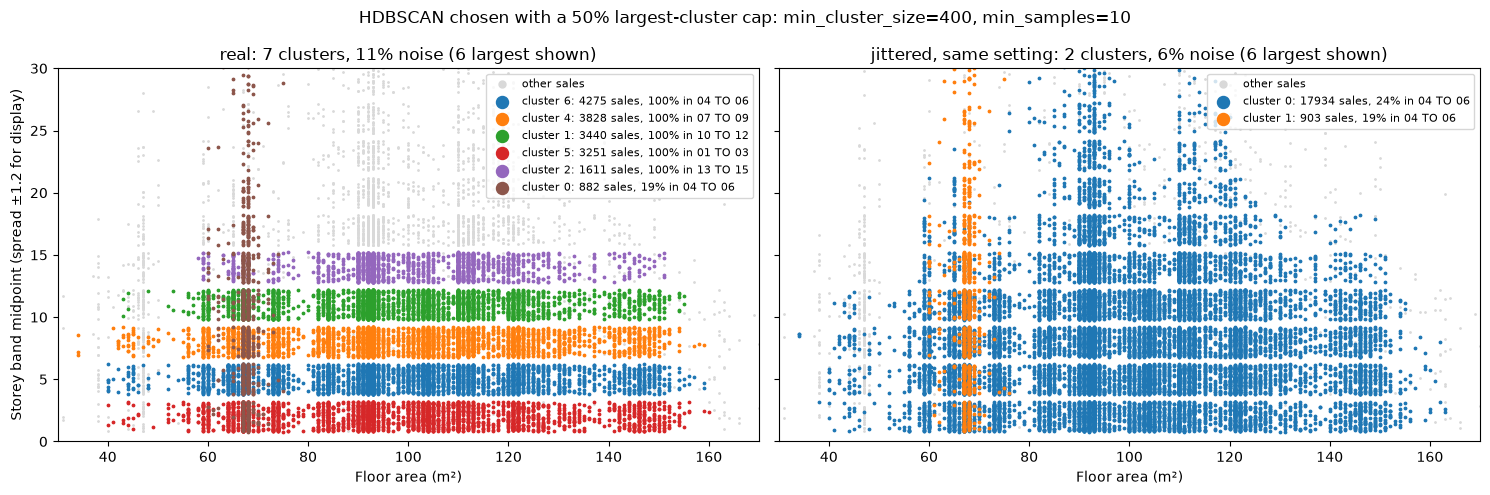

In [5]:
labels = capped_labels["HDBSCAN"]
sizes = pd.Series(labels[labels != NOISE_LABEL]).value_counts()
shown = sizes.index[:6]
jitter_labels = refit_from_grid("HDBSCAN", capped_real["HDBSCAN"], "jittered")

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
display_rng = np.random.default_rng(SEED)
for ax, (title, point_labels) in zip(axes, [("real", labels), ("jittered, same setting", jitter_labels)]):
    storey = sample["storey_mid"].to_numpy() + display_rng.uniform(-1.2, 1.2, len(sample))
    area = sample["floor_area_sqm"].to_numpy()
    ax.scatter(area, storey, s=1, color="#d9d9d9", label="other sales")
    top = pd.Series(point_labels[point_labels != NOISE_LABEL]).value_counts().index[:6]
    for i, cluster in enumerate(top):
        member = point_labels == cluster
        band = pd.Series(storey_band[member]).value_counts(normalize=True)
        ax.scatter(area[member], storey[member], s=3, color=plt.get_cmap("tab10")(i), label=f"cluster {cluster}: {member.sum()} sales, {band.iloc[0]:.0%} in {band.index[0]}")
    counts = len(np.unique(point_labels[point_labels != NOISE_LABEL]))
    ax.set(xlabel="Floor area (m²)", title=f"{title}: {counts} clusters, {np.mean(point_labels == NOISE_LABEL):.0%} noise (6 largest shown)", xlim=(30, 170), ylim=(0, 30))
    ax.legend(markerscale=5, fontsize=8, loc="upper right")
axes[0].set_ylabel("Storey band midpoint (spread ±1.2 for display)")
fig.suptitle(f"HDBSCAN chosen with a 50% largest-cluster cap: {setting_label(capped_real['HDBSCAN'])}")
fig.tight_layout()
fig.savefig(FIGURES / "failure_ties.png", dpi=150)

**Observations**

- **DBSCAN, real data:** any cap from 0.9 down selects eps 0.501, `min_samples` 20: 27 clusters, largest 21.5%, silhouette -0.080. **All 27 clusters are single storey bands**, holding 100% of clustered sales; the median cluster has 68 sales, all of one flat type.
- **HDBSCAN, real data:** a cap of 0.6 or 0.5 selects `min_cluster_size` 400, `min_samples` 10: 7 clusters, largest 21.4%, silhouette 0.017, ARI vs flat type 0.018. **6 of the 7 clusters are single storey bands, holding 95.1% of clustered sales.** The figure shows them as horizontal stripes: 4,275 sales all in 04 TO 06, 3,828 in 07 TO 09, 3,440 in 10 TO 12, 3,251 in 01 TO 03, 1,611 in 13 TO 15. The one cluster that is not a band has 882 sales at about 67 m².
- **Jittered data:** the same HDBSCAN setting gives 2 clusters with 17,934 sales in one. No HDBSCAN setting passes a cap of 0.6 or lower. DBSCAN passes a 0.7 cap only at eps 0.220, `min_samples` 5, with 89 clusters (49 single bands) and silhouette -0.466.
- **The cap does not fix the rule.** On real data it swaps one giant cluster for clusters made of ties. On jittered data no setting has balanced clusters.

**Decision:** do not add the largest-cluster cap. It is reported as a tested improvement that failed, and section 7 shows it would also change LTA.

## 3. Success and failure cases

Each case names the figure that shows it and the data property behind it.

In [6]:
cases = pd.DataFrame(
    [
        {"case": "K-means finds 4 market segments", "outcome": "success", "cause": "continuous features with weak but real joint structure (silhouette 1.45x null)", "figure": "figures/kmeans_clusters.png"},
        {"case": "K-means on raw units cuts price bands", "outcome": "failure", "cause": "scale: price holds all of the squared distance", "figure": "figures/ablation_features.png"},
        {"case": "Density settings chosen by the rule put 97% to 99.7% in one cluster", "outcome": "failure", "cause": "density: one dense core with no gaps; silhouette rewards a giant plus a tiny cluster", "figure": "figures/comparison.png"},
        {"case": "With a 50% cap, HDBSCAN clusters are single storey bands", "outcome": "failure", "cause": "noise in measurement: discrete recorded values create ties", "figure": "figures/failure_ties.png"},
        {"case": "HDBSCAN finds new 3 ROOM flats as a compact group", "outcome": "success", "cause": "density: a standard flat design sold at one lease age forms a real dense spot", "figure": "figures/comparison.png"},
        {"case": "No method recovers flat type from all four features", "outcome": "failure", "cause": "label defined by one feature (floor area); price and storey cut across it", "figure": "figures/kmeans_k_sweep.png"},
        {"case": "HDBSCAN on floor area and lease finds flat designs", "outcome": "success", "cause": "density: each flat design of a building era is a dense spot in size and lease; price and storey blur it", "figure": "figures/success_flat_designs.png"},
    ]
)
cases.to_csv(RESULTS / "cases.csv", index=False)
cases

,case,outcome,cause,figure
0,K-means finds 4 market segments,success,continuous features with weak but real joint s...,figures/kmeans_clusters.png
1,K-means on raw units cuts price bands,failure,scale: price holds all of the squared distance,figures/ablation_features.png
2,Density settings chosen by the rule put 97% to...,failure,density: one dense core with no gaps; silhouet...,figures/comparison.png
3,"With a 50% cap, HDBSCAN clusters are single st...",failure,noise in measurement: discrete recorded values...,figures/failure_ties.png
4,HDBSCAN finds new 3 ROOM flats as a compact group,success,density: a standard flat design sold at one le...,figures/comparison.png
5,No method recovers flat type from all four fea...,failure,label defined by one feature (floor area); pri...,figures/kmeans_k_sweep.png
6,HDBSCAN on floor area and lease finds flat des...,success,density: each flat design of a building era is...,figures/success_flat_designs.png


**Observations**

- 3 successes and 4 failures, each with a named cause and figure. Scale, ties and the definition of the label explain the failures; the successes come from continuous joint structure (K-means segments) and from real dense products (new 3 ROOM flats, flat designs in floor area and lease).

## 4. Preprocessing ablation, one change at a time

K-means (K=4, `n_init=10`) and HDBSCAN at its Stage 3 setting (`min_cluster_size` 200, `min_samples` None) on
each variant of the real data. ARI vs default compares with the same method on the default features. Silhouette
is in each variant's own space.

In [7]:
price_per_sqm = sample["real_price"] / sample["floor_area_sqm"]
variants = {
    "default (4 features, standardized)": X,
    "raw units": sample.to_numpy(),
    "jittered": X_jitter,
    "without lease": standardize(sample.drop(columns="remaining_lease_years")),
    "floor area and lease only": standardize(sample[["floor_area_sqm", "remaining_lease_years"]]),
    "plus price per m²": standardize(sample.assign(price_per_sqm=price_per_sqm)),
}
# Checks for the floor-area-and-lease variant: ties removed, and the same two columns shuffled independently.
area_lease = sample[["floor_area_sqm", "remaining_lease_years"]]
variants["floor area and lease only, jittered"] = standardize(jitter_ties(area_lease, np.random.default_rng(SEED)))
variants["floor area and lease only, shuffled null"] = shuffled_null(standardize(area_lease), np.random.default_rng(SEED))

hdbscan_row = best_density_setting(hdbscan_grid[hdbscan_grid["data"] == "real"].drop(columns="data"))
hdbscan_setting = (int(hdbscan_row["min_cluster_size"]), None if str(hdbscan_row["min_samples"]) == "None" else int(hdbscan_row["min_samples"]))
print("HDBSCAN setting:", hdbscan_setting)

rows, variant_labels = [], {}
for name, data in variants.items():
    for method in ("K-means", "HDBSCAN"):
        model = KMeans(n_clusters=K, n_init=10, random_state=SEED) if method == "K-means" else hdbscan(*hdbscan_setting)
        labels = model.fit_predict(data)
        variant_labels[(method, name)] = labels
        scores = evaluate(data, labels, truth=flat_type, silhouette_sample=SILHOUETTE_SAMPLE, seed=SEED)
        rows.append(
            {
                "variant": name,
                "method": method,
                **scores,
                "ari_vs_default": adjusted_rand_score(variant_labels[(method, "default (4 features, standardized)")], labels),
                "single_storey_clusters": int((single_value_share(labels, storey_band) == 1.0).sum()),
            }
        )
feature_ablation = pd.DataFrame(rows)
feature_ablation.to_csv(RESULTS / "ablation_features.csv", index=False)
feature_ablation

HDBSCAN setting: (200, None)


,variant,method,n_clusters,noise_fraction,largest_cluster_share,silhouette,davies_bouldin,ari,nmi,ari_vs_default,single_storey_clusters
0,"default (4 features, standardized)",K-means,4,0.000,0.352,0.317,1.115,2.140e-01,2.944e-01,1.000e+00,0
1,"default (4 features, standardized)",HDBSCAN,2,0.285,0.686,0.160,1.133,7.218e-02,1.012e-01,1.000e+00,0
2,raw units,K-means,4,0.000,0.399,0.540,0.542,2.292e-01,2.767e-01,2.612e-01,0
3,raw units,HDBSCAN,7,0.316,0.517,0.196,0.405,1.476e-01,1.686e-01,1.734e-01,0
4,jittered,K-means,4,0.000,0.358,0.316,1.119,2.182e-01,2.981e-01,9.415e-01,0
5,jittered,HDBSCAN,2,0.274,0.698,0.150,1.119,6.937e-02,9.562e-02,8.858e-01,0
6,without lease,K-means,4,0.000,0.447,0.317,1.068,4.607e-01,4.869e-01,3.374e-01,0
7,without lease,HDBSCAN,5,0.297,0.189,0.086,3.180,3.318e-03,7.582e-02,1.586e-01,4
8,floor area and lease only,K-means,4,0.000,0.301,0.438,0.848,2.656e-01,3.866e-01,5.190e-01,0
9,floor area and lease only,HDBSCAN,14,0.431,0.091,0.487,0.726,1.269e-01,4.337e-01,1.277e-02,0


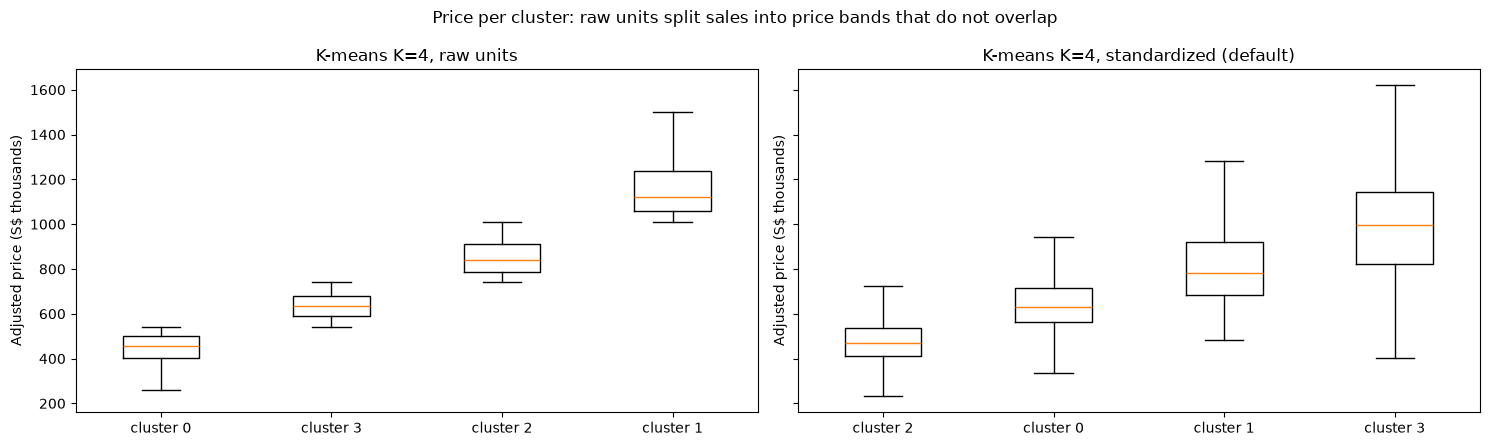

In [8]:
raw_labels = variant_labels[("K-means", "raw units")]
default_labels = variant_labels[("K-means", "default (4 features, standardized)")]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for ax, (title, labels) in zip(axes, [("raw units", raw_labels), ("standardized (default)", default_labels)]):
    order = pd.Series(sample["real_price"].to_numpy()).groupby(labels).median().sort_values().index
    ax.boxplot([sample["real_price"].to_numpy()[labels == c] / 1000 for c in order], showfliers=False)
    ax.set_xticks(range(1, K + 1), [f"cluster {c}" for c in order])
    ax.set(title=f"K-means K={K}, {title}", ylabel="Adjusted price (S$ thousands)")
fig.suptitle("Price per cluster: raw units split sales into price bands that do not overlap")
fig.tight_layout()
fig.savefig(FIGURES / "ablation_features.png", dpi=150)

**Observations**

- **Raw units:** K-means reaches silhouette 0.540 but agrees with the default partition at only ARI 0.261. The figure shows why: on raw units the 4 clusters are price bands whose boxes and whiskers do not overlap (about S$260,000 to S$540,000, S$540,000 to S$740,000, S$740,000 to S$1,010,000, and above). With standardized features, prices overlap between all clusters. HDBSCAN on raw units gives 7 clusters and 31.6% noise, agreeing with its default at ARI 0.173.
- **Jitter** barely changes either method at these settings (ARI vs default 0.942 K-means, 0.886 HDBSCAN).
- **Without lease**, K-means matches flat type at ARI 0.461 (default 0.214). HDBSCAN splits into 5 clusters, 4 of them single storey bands, because storey is then one of only three features.
- **Plus price per m²** changes little: K-means ARI vs default 0.586, flat type 0.190; HDBSCAN 2 clusters, ARI vs default 0.776.
- **Floor area and lease only** changes HDBSCAN the most: 14 clusters, 43.1% noise, largest 9.1%, silhouette 0.487, NMI vs flat type 0.434 (default: 2 clusters, NMI 0.101). K-means on the same two features: silhouette 0.438, ARI vs default 0.519.
- **The silhouette of that variant is close to its null:** the shuffled floor area and lease give 10 clusters, 46.4% noise and silhouette 0.441, but NMI vs flat type 0.001. With only 2 features each column is already clumped, so the shuffled null keeps dense spots (the same limitation as for earthquake coordinates, `../AGENTS.md`). Jittered, the variant gives 12 clusters, 33.8% noise, silhouette 0.573, NMI 0.483. The next cell checks what the clusters contain.

### Floor area and lease only: what HDBSCAN finds

The silhouette of this variant is close to its shuffled null, so the check here is external: does each cluster
hold one flat type and one flat model? A shuffled null cannot produce that, because shuffling breaks the link
between a sale's floor area, lease and flat type.

In [9]:
def design_profile(labels):
    frame = sample.assign(cluster=labels, flat_type=flat_type, flat_model=sales["flat_model"].to_numpy())
    grouped = frame[frame["cluster"] != NOISE_LABEL].groupby("cluster")
    return pd.DataFrame(
        {
            "sales": grouped.size(),
            "floor area median": grouped["floor_area_sqm"].median(),
            "lease median": grouped["remaining_lease_years"].median(),
            "top flat type": grouped["flat_type"].agg(lambda v: v.value_counts().index[0]),
            "top flat type share": grouped["flat_type"].agg(lambda v: v.value_counts(normalize=True).iloc[0]),
            "top flat model": grouped["flat_model"].agg(lambda v: v.value_counts().index[0]),
            "top flat model share": grouped["flat_model"].agg(lambda v: v.value_counts(normalize=True).iloc[0]),
        }
    ).sort_values("sales", ascending=False)


design_profiles = []
for name in ["floor area and lease only", "floor area and lease only, jittered"]:
    profile = design_profile(variant_labels[("HDBSCAN", name)])
    print(f"{name}: {len(profile)} clusters; clusters with one flat type at 100%: {int((profile['top flat type share'] == 1.0).sum())}; lowest top flat type share: {profile['top flat type share'].min():.0%}")
    display(profile)
    design_profiles.append(profile.assign(variant=name))
pd.concat(design_profiles).to_csv(RESULTS / "ablation_flat_design_clusters.csv")
feature_ablation[feature_ablation["variant"].str.startswith("floor area and lease") & (feature_ablation["method"] == "HDBSCAN")][["variant", "n_clusters", "noise_fraction", "largest_cluster_share", "silhouette", "ari", "nmi"]]

floor area and lease only: 14 clusters; clusters with one flat type at 100%: 6; lowest top flat type share: 84%


,sales,floor area median,lease median,top flat type,top flat type share,top flat model,top flat model share
cluster,,,,,,,
10,1817,104.0,69.750,4 ROOM,0.999,Model A,0.954
8,1427,67.0,57.750,3 ROOM,1.000,New Generation,0.732
6,1303,121.0,71.417,5 ROOM,0.993,Improved,0.938
12,1102,93.0,94.250,4 ROOM,1.000,Model A,0.842
11,954,110.0,80.500,5 ROOM,0.973,Improved,0.711
1,932,68.0,93.167,3 ROOM,0.999,Model A,0.828
5,846,113.0,93.833,5 ROOM,0.999,Improved,0.712
2,817,146.0,69.333,EXECUTIVE,0.982,Maisonette,0.518
3,461,84.0,63.167,4 ROOM,0.839,Simplified,0.826


floor area and lease only, jittered: 12 clusters; clusters with one flat type at 100%: 3; lowest top flat type share: 85%


,sales,floor area median,lease median,top flat type,top flat type share,top flat model,top flat model share
cluster,,,,,,,
9,2771,93.0,93.500,4 ROOM,1.000,Model A,0.762
3,2411,67.0,59.167,3 ROOM,1.000,New Generation,0.509
10,1852,104.0,69.833,4 ROOM,0.999,Model A,0.952
7,1201,122.0,71.583,5 ROOM,0.994,Improved,0.941
11,967,110.0,80.417,5 ROOM,0.971,Improved,0.703
1,933,68.0,93.167,3 ROOM,0.999,Model A,0.829
4,843,113.0,93.833,5 ROOM,0.999,Improved,0.713
2,827,146.0,69.250,EXECUTIVE,0.976,Maisonette,0.516
5,451,84.0,63.167,4 ROOM,0.849,Simplified,0.836


,variant,n_clusters,noise_fraction,largest_cluster_share,silhouette,ari,nmi
9,floor area and lease only,14,0.431,0.091,0.487,1.269e-01,4.337e-01
13,"floor area and lease only, jittered",12,0.338,0.139,0.573,1.962e-01,4.826e-01
15,"floor area and lease only, shuffled null",10,0.464,0.147,0.441,-2.731e-04,8.085e-04


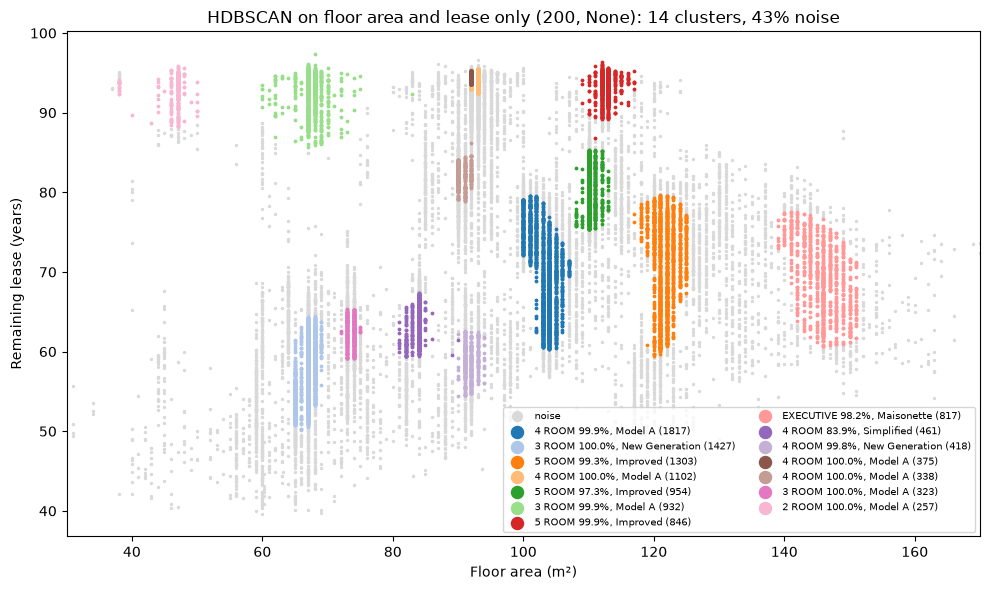

In [10]:
labels = variant_labels[("HDBSCAN", "floor area and lease only")]
fig, ax = plt.subplots(figsize=(10, 6))
noise = labels == NOISE_LABEL
ax.scatter(sample["floor_area_sqm"][noise], sample["remaining_lease_years"][noise], s=2, color="#d9d9d9", label="noise")
profile = design_profile(labels)
for i, cluster in enumerate(profile.index):
    member = labels == cluster
    row = profile.loc[cluster]
    ax.scatter(sample["floor_area_sqm"][member], sample["remaining_lease_years"][member], s=3, color=plt.get_cmap("tab20")(i % 20), label=f"{row['top flat type']} {row['top flat type share']:.1%}, {row['top flat model']} ({int(row['sales'])})")
ax.set(xlabel="Floor area (m²)", ylabel="Remaining lease (years)", xlim=(30, 170), title=f"HDBSCAN on floor area and lease only ({hdbscan_setting[0]}, {hdbscan_setting[1]}): {len(profile)} clusters, {noise.mean():.0%} noise")
ax.legend(markerscale=5, fontsize=7, loc="lower right", ncol=2)
fig.tight_layout()
fig.savefig(FIGURES / "success_flat_designs.png", dpi=150)

**Observations**

- **Each cluster is one flat design of one building era.** On real data, 13 of the 14 clusters are at least 97% one flat type (6 of them exactly 100%); the lowest is 83.9%, a 4 ROOM cluster at 84 m² that is 82.6% `Simplified`. Most are dominated by one flat model: e.g. 1,817 sales of 4 ROOM `Model A` at 104 m² with 69.8 years left (95% `Model A`); 1,427 of 3 ROOM `New Generation` at 67 m² with 57.8 years (73%); 1,303 of 5 ROOM `Improved` at 121 m² with 71.4 years (94%); 817 EXECUTIVE at 146 m² with 69.3 years (98% one type, 52% `Maisonette`).
- The same design appears at different lease ages as separate clusters: 4 ROOM `Model A` near 93 m² at 94.3 and 94.6 years left, and 4 ROOM at about 92 m² with 58.8 years (97% `New Generation`).
- **Jittered data finds the same designs:** 12 clusters, again each at least 84.9% one flat type. The two 4 ROOM `Model A` clusters near 93 m² merge into one of 2,771 sales, and the 3 ROOM cluster at 67 m² grows from 1,427 to 2,411 sales.
- The null shows clumps but not designs (NMI 0.001), so density structure in this data is real in floor area and lease, and hidden when price and storey are added.

**Decision:** report this as the density-method success on HDB. The evidence is flat type and flat model purity, not silhouette against the null.

## 5. Subsample stability

Five random subsamples of 16,000 of the 20,000 sales (80%, seeds 0 to 4). Each pair of subsamples shares about
12,800 sales; ARI is computed on those shared sales for all 10 pairs. Settings are unchanged, so density methods
see 20% fewer sales with the same `min_cluster_size` or eps.

In [11]:
dbscan_row = best_density_setting(dbscan_grid[dbscan_grid["data"] == "real"].drop(columns="data"))
methods = {
    "K-means": lambda: KMeans(n_clusters=K, n_init=10, random_state=SEED),
    "DBSCAN (real)": lambda: dbscan(dbscan_row["eps"], int(dbscan_row["min_samples"])),
    "HDBSCAN (real)": lambda: hdbscan(*hdbscan_setting),
    "HDBSCAN (jittered)": lambda: hdbscan(*hdbscan_setting),
    "HDBSCAN capped (real)": lambda: hdbscan(int(capped_real["HDBSCAN"]["min_cluster_size"]), None if str(capped_real["HDBSCAN"]["min_samples"]) == "None" else int(capped_real["HDBSCAN"]["min_samples"])),
}
subsets = [np.sort(np.random.default_rng(seed).choice(SAMPLE_SIZE, size=16_000, replace=False)) for seed in range(5)]

rows = []
for method, make in methods.items():
    data = X_jitter if "jittered" in method else X
    runs = [(rows_i, make().fit_predict(data[rows_i])) for rows_i in subsets]
    for i in range(len(runs)):
        for j in range(i + 1, len(runs)):
            shared, ia, ib = np.intersect1d(runs[i][0], runs[j][0], return_indices=True)
            rows.append({"method": method, "pair": f"{i}-{j}", "shared_sales": len(shared), "ari": adjusted_rand_score(runs[i][1][ia], runs[j][1][ib]), "n_clusters_i": len(set(runs[i][1]) - {NOISE_LABEL}), "n_clusters_j": len(set(runs[j][1]) - {NOISE_LABEL})})
stability = pd.DataFrame(rows)
stability.to_csv(RESULTS / "ablation_subsample_stability.csv", index=False)
stability.groupby("method").agg(
    median_ari=("ari", "median"), min_ari=("ari", "min"), max_ari=("ari", "max"),
    clusters_min=("n_clusters_i", "min"), clusters_max=("n_clusters_i", "max"), shared_sales=("shared_sales", "median"),
)

,median_ari,min_ari,max_ari,clusters_min,clusters_max,shared_sales
method,,,,,,
DBSCAN (real),0.920,0.890,0.929,3,6,12804.5
HDBSCAN (jittered),0.955,0.924,0.969,2,2,12804.5
HDBSCAN (real),0.930,0.905,0.970,2,2,12804.5
HDBSCAN capped (real),0.987,0.984,0.988,7,7,12804.5
K-means,0.974,0.941,0.990,4,4,12804.5


**Observations**

- Every method is stable across 80% subsamples (10 pairs, about 12,800 shared sales each): K-means median ARI 0.974 (0.941 to 0.990), HDBSCAN real 0.930 and jittered 0.955, DBSCAN real 0.920 (3 to 6 clusters between subsamples).
- **The most stable result is the capped HDBSCAN setting, whose clusters are storey bands:** median ARI 0.987, always 7 clusters. Storey bands are the same in every subsample, so a tie artefact is reproduced exactly. High stability does not show that clusters are meaningful.

## 6. Scalability

From `experiments/scalability.py`: random subsets of all 234,294 sales (standardized on all sales), each method at
its Stage 3 setting. Sizes up to 20,000 run 3 times (median shown); larger sizes once. Slopes are fitted on sizes
of 5,000 and above, where fixed overheads matter less. Runtimes depend on the machine (Apple M2, 16 GB).

In [12]:
scalability = pd.read_csv(RESULTS / "scalability.csv")
if "skipped" in scalability.columns:
    skipped = scalability[scalability["skipped"].notna()]
    print("skipped runs:")
    print(skipped[["method", "n", "skipped"]].to_string(index=False) if len(skipped) else "none")
    timed = scalability[scalability["skipped"].isna()]
else:
    timed = scalability
runtime = timed.groupby(["method", "n"]).agg(seconds=("seconds", "median"), n_clusters=("n_clusters", "median"), noise_fraction=("noise_fraction", "median"), largest=("largest_cluster_fraction", "median")).reset_index()

slopes = {}
for method, part in runtime[runtime["n"] >= 5_000].groupby("method"):
    if len(part) >= 2:
        slopes[method] = np.polyfit(np.log(part["n"]), np.log(part["seconds"]), 1)[0]
display(runtime.pivot(index="n", columns="method", values="seconds"))
display(pd.Series(slopes, name="log-log slope (n ≥ 5,000)").to_frame())
runtime.to_csv(RESULTS / "scalability_summary.csv", index=False)

skipped runs:
method      n                               skipped
DBSCAN 234294 estimated 741,656,134 neighbour pairs


method,DBSCAN,HDBSCAN,K-means (random),K-means++
n,,,,
1000,0.004,0.025,0.002,0.002
2000,0.011,0.060,0.006,0.007
5000,0.049,0.212,0.008,0.003
10000,0.135,0.623,0.006,0.007
20000,0.421,1.962,0.010,0.010
50000,1.967,10.068,0.017,0.018
100000,6.809,37.456,0.030,0.027
234294,NaN,212.078,0.058,0.048


,"log-log slope (n ≥ 5,000)"
DBSCAN,1.653
HDBSCAN,1.793
K-means (random),0.571
K-means++,0.666


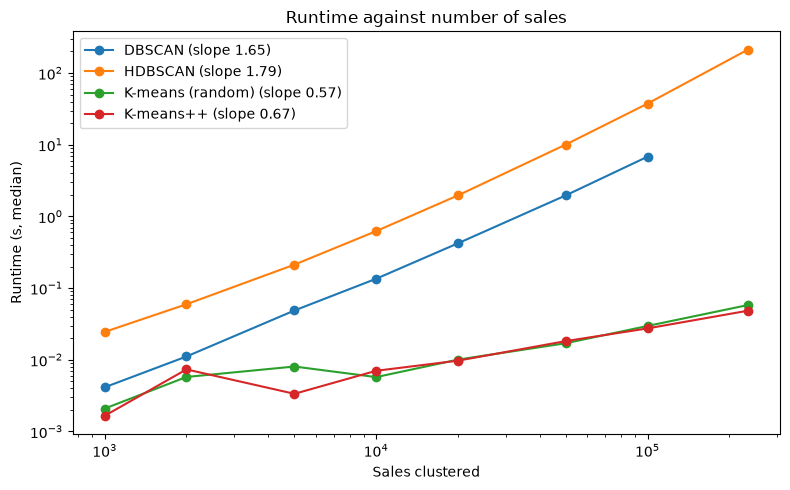

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for method, part in runtime.groupby("method"):
    label = f"{method} (slope {slopes[method]:.2f})" if method in slopes else method
    ax.plot(part["n"], part["seconds"], "o-", label=label)
ax.set(xscale="log", yscale="log", xlabel="Sales clustered", ylabel="Runtime (s, median)", title="Runtime against number of sales")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "scalability.png", dpi=150)

**Observations**

- **K-means** stays under 0.06 s up to all 234,294 sales (slope 0.57 random, 0.67 K-means++). At these times fixed overheads dominate, so the slope is not the algorithm's growth.
- **DBSCAN** grows with slope 1.65: 0.42 s at 20,000, 6.8 s at 100,000. At all 234,294 sales it was **skipped for memory, not time**: the estimated 742 million neighbour pairs within eps would need about 6 GB for the neighbour indices alone (sklearn's DBSCAN keeps every neighbourhood as int64 indices, 8 bytes each), on a 16 GB machine. At a fixed eps each sale's neighbour count grows with the data size, so memory grows roughly with n².
- **HDBSCAN** grows with slope 1.79: 2.0 s at 20,000, 37.5 s at 100,000 and 212 s at all sales. Part of the full-size run overlapped with an earlier run of this notebook, so 212 s may be slightly high; the slope from 100,000 would predict about 170 s.
- On earthquakes (500 to 7,643 points, `../sc4020-earthquake/results/scalability.csv`) the HDBSCAN slope is 1.75 to 1.85 depending on the smallest size included, consistent with this, on a different distance and 20 to 30 times fewer points.

## 7. Cross-dataset comparison

Chosen settings on each dataset, from `../sc4020-earthquake/results/cross_dataset_comparison.csv` (earthquakes and
LTA) and this project's `results/comparison.csv` (HDB, real data). Each dataset uses its own features and
distance, so silhouettes compare how clear the structure is within each dataset, not across them.

In [14]:
other = pd.read_csv(ROOT.parent / "sc4020-earthquake" / "results" / "cross_dataset_comparison.csv")
hdb_rows = comparison[comparison["data"] == "real"].assign(dataset="HDB resale")[other.columns.drop("seconds").tolist() + ["seconds"]]
cross = pd.concat([other, hdb_rows], ignore_index=True)
cross["over 50% largest-cluster cap"] = cross["largest_cluster_share"] > 0.5
cross.to_csv(RESULTS / "cross_dataset_comparison.csv", index=False)
cross

,dataset,method,setting,n_clusters,noise_fraction,largest_cluster_share,silhouette,null_silhouette,davies_bouldin,seconds,over 50% largest-cluster cap
0,earthquakes,K-means (random),"K=6, n_init=1",6.0,0.000,0.443,0.525,0.389,0.800,4.304e-03,False
1,earthquakes,K-means++,"K=6, n_init=1",6.0,0.000,0.310,0.528,0.391,0.738,5.043e-03,False
2,earthquakes,DBSCAN,"eps=101.8 km, min_samples=20",41.0,0.404,0.118,0.703,NaN,0.351,5.148e-02,False
3,earthquakes,HDBSCAN,"min_cluster_size=50, min_samples=default",28.0,0.307,0.075,0.757,0.320,0.329,1.081e+00,False
4,LTA train,K-means (random),"K=4, n_init=1",4.0,0.000,0.486,0.260,0.067,1.313,1.539e-03,False
5,LTA train,K-means++,"K=4, n_init=1",4.0,0.000,0.481,0.257,0.066,1.332,7.653e-04,False
6,LTA train,DBSCAN,"eps=0.0686 (p75), min_samples=5",2.0,0.135,0.816,0.487,NaN,0.595,1.226e-03,True
7,LTA train,HDBSCAN,"min_cluster_size=5, min_samples=default",2.0,0.416,0.551,0.497,NaN,0.533,3.156e-03,True
8,LTA bus,K-means (random),"K=5, n_init=1",5.0,0.000,0.299,0.204,0.082,1.483,1.490e-02,False
9,LTA bus,K-means++,"K=5, n_init=1",5.0,0.000,0.299,0.204,0.133,1.483,1.793e-02,False


**Observations**

- **HDB is the only dataset where the density rule's settings score below the shuffled null** (DBSCAN 0.239 vs 0.330, HDBSCAN 0.160 vs 0.593). Earthquake HDBSCAN scores 0.757 vs 0.320. For LTA and earthquake DBSCAN no null silhouette was recorded.
- **A 50% largest-cluster cap would change 5 chosen settings:** HDB DBSCAN (97.1%) and HDBSCAN (68.6%), LTA train DBSCAN (81.6%) and HDBSCAN (55.1%), and LTA bus DBSCAN (79.5%). Earthquake settings all pass (largest at most 44.3%). Section 2 shows the cap selects tie clusters on HDB, so it is not proposed for the other datasets.
- K-means silhouette relative to its null: earthquakes 1.35x (0.528 vs 0.391), LTA train 3.9x (0.260 vs 0.067), HDB 1.45x (0.317 vs 0.218), using the K-means++ null for LTA train. LTA bus is 2.5x for random init and 1.5x for K-means++, because the null differs between the two rows.

## 8. Key factors and summary

**Key factors.** The data property that most changes how the methods rank on HDB:

| Factor | Evidence | Effect |
|---|---|---|
| Scale | Raw units: K-means price bands, silhouette 0.540 but ARI 0.261 with standardized (section 4) | Silhouette prefers the wrong partition unless features are standardized |
| Ties from recorded values | With a 50% cap, 27 of 27 DBSCAN and 6 of 7 HDBSCAN clusters are single storey bands; jittered data has no such clusters (section 2) | Density methods find recording steps, not groups; stability rewards them (ARI 0.987, section 5) |
| Feature choice | Floor area and lease only: HDBSCAN finds 12 to 14 flat designs, NMI 0.434 to 0.483; with price and storey: 2 clusters, NMI 0.101 (section 4) | Density structure exists in two features and is hidden in four |
| Label definition | Floor area alone matches flat type at ARI 0.649; all four features at most 0.256 (Stage 3) | ARI against flat type measures floor area |
| Selection metrics | Density rule chooses 97% to 99.7% one-cluster settings; the cap chooses ties; the null silhouette of 2 features is close to real (sections 2, 4) | No single internal metric identifies the good density result; content checks against labels do |
| Size | DBSCAN memory about 12 GB at 234,294 sales; HDBSCAN 212 s (section 6) | K-means is the only method run at full size at no cost |

**What this gives the report (HDB's role).** Real data with labels where internal metrics mislead: silhouette favours raw price bands and giant-plus-tiny density partitions, stability favours tie clusters, and ARI against flat type measures floor area. K-means gives 4 market segments on all four features. Density methods succeed only on floor area and lease, where HDBSCAN finds flat designs of each building era, confirmed by flat type and flat model rather than by silhouette.

**Improvements tested:** standardizing (needed); jitter (removes tie clusters at fine settings, no effect at the chosen ones); largest-cluster cap (fails, not adopted); feature selection (floor area and lease reveals density structure).

**For the group:** keep the density selection rule unchanged across datasets, and state on HDB that it fails and why. The flat-design result uses a feature set chosen after seeing results, so it is reported as an ablation finding, not as the chosen setting.